In [2]:
from spin_lattices import KagomeLattice, SpinLattice, SquareLattice, TriangleLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from pathlib import Path
import torch
from tqdm.auto import tqdm
from torch.optim import Adam
import numpy as np
import numpy.typing as npt
from misc_utils import make_unpacked_configurations

import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

import matplotlib.pyplot as plt

from sympy.combinatorics import Permutation
from sympy.combinatorics.perm_groups import PermutationGroup

from collections.abc import Iterable


2023-06-21 17:27:53.310 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-06-21 17:27:53.313 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
[Debug]   [LOCALE0]   Initializing chpl_kernels ...
2023-06-21 17:27:53.362 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
set_python_exception_handler ...


In [3]:
%matplotlib inline

In [4]:
### FROM: https://stackoverflow.com/a/2158532/3025981
def flatten(xs):
    for x in xs:
        if isinstance(x, Iterable) and not isinstance(x, (str, bytes, Permutation)):
            yield from flatten(x)
        else:
            yield x
### END FROM

In [5]:
def vis_permutation(lat: SpinLattice, permutation: list[int]):
    lat.plot()
    for _, row in lat.sites_df.iterrows():
        plt.text(row['emb_x'] + 0.2, row['emb_y'] + 0.2, "(" + str(permutation[row['num']]) + ")")

def generate_group(permutations):
    sympy_perms = [Permutation(p) for p in permutations]
    G = PermutationGroup(*sympy_perms)
    return [tuple(x.array_form) for x in G.generate()]

In [6]:
lat = KagomeLattice(2, 3, enumerate_along='x')
df = lat.sites_df.query('is_canonical').reset_index()

In [7]:
automorphisms = sorted(map(tuple, lat.get_automorphisms()))
symmetry_idx = automorphisms.index([x for x in automorphisms if x[0] == 0][1])
generators = dict(
    x_translation=lat.get_translation("x"),
    y_translation=lat.get_translation("y"),
    central_symmetry=automorphisms[symmetry_idx],
)

subgroup = generate_group(generators.values())
rest = list(set(automorphisms) - set(subgroup))
assert not rest

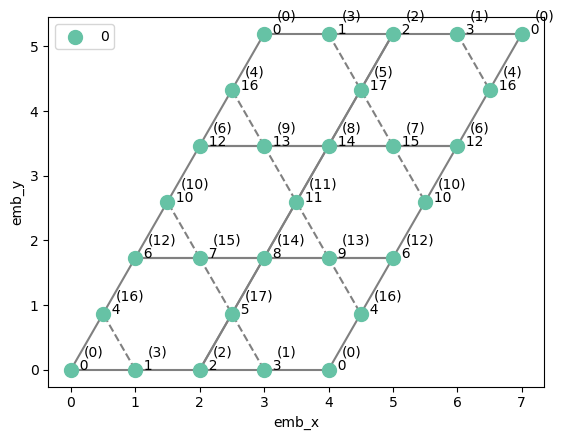

In [8]:
vis_permutation(lat, generators['central_symmetry'])

In [9]:
translation_group = PermutationGroup(
    *[Permutation(p) for p in [lat.get_translation("x"), lat.get_translation("y")]]
)

Test that any element can be represented as $ts$ where $t$ is a translation and $s$ is either identity or central symmetry.

In [10]:
central_symmetry = PermutationGroup(Permutation(generators['central_symmetry']))

ts_elements = [
    tuple((t * s).array_form)
    for t in translation_group.generate()
    for s in central_symmetry.generate()
]
assert not (set(automorphisms) - set(ts_elements))

In [11]:
tx = Permutation(generators['x_translation'])
ty = Permutation(generators['y_translation'])
assert tx * ty == ty * tx

sym = Permutation(generators['central_symmetry'])

In [133]:
group: dict[tuple[int, int, int], Permutation] = {
    (c, a, b): tx**a * ty**b * sym**c for c in range(2) for b in range(lat.height)
    for a in range(lat.width)
}

In [134]:
assert set(tuple(x.array_form) for x in group.values()) == set(automorphisms)
assert group[0, 0, 0] == Permutation(lat.number_spins - 1)
assert group[1, 0, 0] == sym
assert group[0, 1, 0] == tx
assert group[0, 0, 1] == ty

In [135]:
p = group[0, 0, 1]
{
    from_: [to_ for to_, perm in group.items() if perm == p * permutation][0]
    for from_, permutation in group.items()
}

{(0, 0, 0): (0, 0, 1),
 (0, 1, 0): (0, 1, 1),
 (0, 0, 1): (0, 0, 2),
 (0, 1, 1): (0, 1, 2),
 (0, 0, 2): (0, 0, 0),
 (0, 1, 2): (0, 1, 0),
 (1, 0, 0): (1, 0, 1),
 (1, 1, 0): (1, 1, 1),
 (1, 0, 1): (1, 0, 2),
 (1, 1, 1): (1, 1, 2),
 (1, 0, 2): (1, 0, 0),
 (1, 1, 2): (1, 1, 0)}

In [136]:
system = HeisenbergJ1J2(
    lat,
    J2=0.8,
    use_symmetries=True,
    spin_inversion=1,
    ground_state_cache_dir=Path("groundstates"),
    skip_symmetries_whitelist=True,
)
system.get_eigenstates(1)
df = system.get_df_ground_state()

2023-06-21 19:21:52.478 | WARNING  | heisenberg_hamiltonians:__init__:414 - Symmetries are not tested with KagomeLattice2x3-enumerate-along-x, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.
2023-06-21 19:21:52.481 | DEBUG    | heisenberg_hamiltonians:__init__:446 - number_spins=18
2023-06-21 19:21:52.489 | DEBUG    | heisenberg_hamiltonians:__init__:456 - Symmetry group contains 12 elements
2023-06-21 19:21:52.490 | DEBUG    | heisenberg_hamiltonians:__init__:465 - Hilbert space dimension is 2102
2023-06-21 19:21:52.500 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:60 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-enumerate-along-x-1.0-0.8-True-1-1.pickle
2023-06-21 19:21:52.502 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state energy is -29.4963743253
2023-06-21 19:21:52.503 | DEBUG    | heisenberg_hamiltonians:get_ground_state_in_canonical_basis:215

In [137]:
X_ = make_unpacked_configurations(df.index, number_spins=lat.number_spins)
X = torch.tensor(
    X_[..., lat.num_tensor_order].astype(np.float32).reshape(-1, lat.width, lat.height, 3)
).permute(0, 3, 1, 2)

In [138]:
def tensor_to_spin_config(lat: SpinLattice, tensor: torch.Tensor):
    np_arr = tensor.permute(0, 2, 3, 1).numpy().astype(np.int8).reshape(-1, lat.number_spins)
    return np_arr[..., (~Permutation(lat.num_tensor_order)).array_form]

In [139]:
assert (tensor_to_spin_config(lat, X) == X_).all()

In [140]:
def g_on_input_tensor(lat: SpinLattice, tensor: torch.Tensor, g: Permutation):
    spin_config = tensor_to_spin_config(lat, tensor)
    transformed = spin_config[:, (~g).array_form]
    return torch.tensor(
        transformed[..., lat.num_tensor_order].reshape(-1, lat.width, lat.height, 3)
    ).permute(0, 3, 1, 2)

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

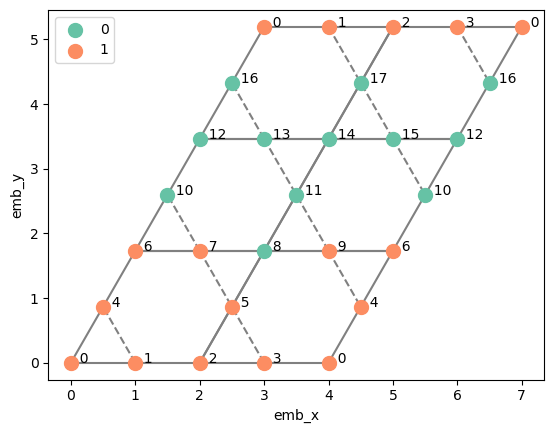

In [141]:
lat.plot(spins=tensor_to_spin_config(lat, X[1:2])[0])

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

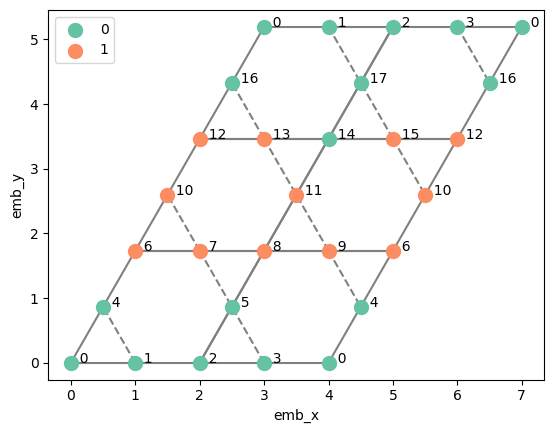

In [142]:
lat.plot(spins=tensor_to_spin_config(lat, g_on_input_tensor(lat, X[1:2], group[0, 0, 1]))[0])

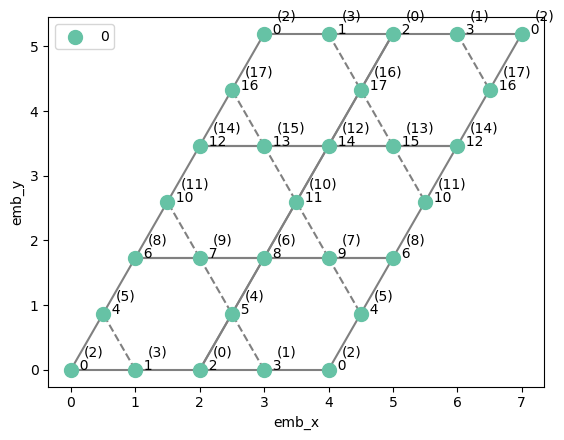

In [143]:
vis_permutation(lat, group[0, 1, 0].array_form)

In [144]:
def perm_to_coords(group: dict[tuple[int, int, int], Permutation], perm: Permutation):
    variants = [k for k, v in group.items() if v == perm]
    assert len(variants) == 1
    return variants[0]

In [157]:
def g_to_substitution(group: dict[tuple[int, int, int], Permutation], g: Permutation):
    return {coords: perm_to_coords(group, (~g) * perm) for coords, perm in group.items()}

In [169]:
g_to_substitution(group, group[1, 1, 1])

{(0, 0, 0): (1, 1, 1),
 (0, 1, 0): (1, 0, 1),
 (0, 0, 1): (1, 1, 0),
 (0, 1, 1): (1, 0, 0),
 (0, 0, 2): (1, 1, 2),
 (0, 1, 2): (1, 0, 2),
 (1, 0, 0): (0, 1, 1),
 (1, 1, 0): (0, 0, 1),
 (1, 0, 1): (0, 1, 0),
 (1, 1, 1): (0, 0, 0),
 (1, 0, 2): (0, 1, 2),
 (1, 1, 2): (0, 0, 2)}

In [172]:
def g_on_signal_on_group(
    group: dict[tuple[int, int, int], Permutation], g: Permutation, signal: torch.Tensor
):
    # new_signal = torch.zeros_like(signal)
    # for to_, from_ in g_to_substitution(group, g).items():
    #     new_signal[to_] = signal[from_]
    # return new_signal
    # Convert the keys and values of the dictionary to lists
    subs = g_to_substitution(group, g)
    to_indices, from_indices = zip(*subs.items())

    # Convert the lists to tensors
    to_indices = torch.tensor(to_indices).T
    from_indices = torch.tensor(from_indices).T

    # Create a new tensor of zeros with the same shape as signal
    new_signal = torch.zeros_like(signal)

    # Use the tensors to index into signal and assign the values to new_signal
    new_signal[tuple(to_indices)] = signal[tuple(from_indices)]
    return new_signal

In [173]:
signal = torch.Tensor(
    [
        [[1, 2, 3], [4, 5, 6]],
        [[7, 8, 9], [10, 11, 12]],
    ]
)
signal.shape

torch.Size([2, 2, 3])

In [174]:
np.array(list(group.keys())).max(axis=0) + 1

array([2, 2, 3])

In [178]:
g_on_signal_on_group(group, sym, signal)

tensor([[[ 7.,  9.,  8.],
         [10., 12., 11.]],

        [[ 1.,  3.,  2.],
         [ 4.,  6.,  5.]]])

In [190]:
g_on_input_tensor(lat, torch.arange(18).view(-1, 3, 2, 3), sym)

tensor([[[[ 0,  2,  1],
          [ 3,  5,  4]],

         [[ 9, 11, 10],
          [ 6,  8,  7]],

         [[14, 13, 12],
          [17, 16, 15]]]], dtype=torch.int8)

In [187]:
torch.arange(18).view(-1, 3, 2, 3)

tensor([[[[ 0,  1,  2],
          [ 3,  4,  5]],

         [[ 6,  7,  8],
          [ 9, 10, 11]],

         [[12, 13, 14],
          [15, 16, 17]]]])